# Predicting Burnout Risk When Working From Home

This project analyzes work-from-home behavioral data to predict burnout risk and understand key drivers of burnout. We use classification models to predict whether an employee is Low Risk or At Risk, estimation models to explain burnout intensity, and clustering models to identify employee behavioral profiles.

In [1]:
# =========================================================
# 0. Imports
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC

from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

sns.set_theme(style="whitegrid")

## 1. Data Description and Preprocessing


In [2]:
data = pd.read_csv('wfh_burnout_dataset.csv')
data.shape

(2000, 14)

In [3]:
# Display first few rows
data.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


The dataset was first examined to understand its structure and quality. It contains 2,000 observations and 14 variables Each row represents a single employee's day observations, capturing work behavior, productivity, and well-being metrics.

In [4]:
# Inspaect data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB


Inspection of data types reveals that most variables are numerical, with the exception of day_type, which is categorical, and burnout_risk, which serves as the target variable.

In [5]:
# Display the top columns with the most missing data
missing_percentage = data.isnull().mean().sort_values(ascending=False)
missing_percentage.head(15)

,0
user_id,0.0
day_type,0.0
work_hours,0.0
screen_time_hours,0.0
meetings_count,0.0
breaks_taken,0.0
after_hours_work,0.0
app_switches,0.0
sleep_hours,0.0
task_completion,0.0


After conductiong the analysis of missing values we can see that there are no missing entries in any of the dataset's columns. As a result, no imputation or removal of observations is required due to missing values.

In [6]:
data = data.drop("user_id", axis=1)

The user_id column was removed from the dataset, as it functions solely as a unique identifier and does not contribute meaningful information for predicting burnout risk. Retaining such a feature could introduce noise and negatively impact model performance later on.

In [7]:
data = pd.get_dummies(data, columns=["day_type"], drop_first=True)

The categorical variable day_type was transformed into a numerical format using one-hot encoding. Since day_type only contains two categories (Weekday and Weekend), one binary variable was sufficient to represent this feature.

In [8]:
X = data.drop("burnout_risk", axis=1)
y = data["burnout_risk"]

The dataset was divided into input features and a target variable. All columns except burnout_risk were used as input features (X), while burnout_risk was selected as the target variable (y). This separation allows the model to learn relationships between employee behavior and burnout risk.

In [9]:
y.value_counts(normalize=True)

,proportion
burnout_risk,
Low,0.5095
Medium,0.4215
High,0.0690


The distribution of the target variable was analyzed to check for class imbalance. The results show that approximately 50.9% of observations are Low risk, 42.2% are Medium risk, and only 6.9% are High risk. This indicates that the dataset is imbalanced, with the High burnout category being underrepresented.

In [10]:
y = y.replace({'Low': 0, 'Medium': 1, 'High': 1})

/tmp/ipykernel_3239/1635877906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Low': 0, 'Medium': 1, 'High': 1})


In [11]:
y.value_counts(normalize=True)

,proportion
burnout_risk,
0,0.5095
1,0.4905


Due to this imbalance in the target variable, the Medium and High categories were combined into a single "at-risk" class. This transformation converts the problem into a binary classification task, improving class balance and allowing the model to better learn patterns associated with burnout risk. Now, there are approximately 50.9% classified as Low risk and 49.1% classified At Risk.




In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

The data was split into training and testing sets using an 80/20 split. This allows the model to be trained on one portion of the data and evaluated on unseen data.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Since the dataset contains features with different ranges, standardization was applied using a standard scaler. This ensures that all features are on a similar scale, preventing variables with larger values from dominating the model. The scaler was fit on the training data and then applied to the test data to avoid data leakage.



In [14]:
X_train.head()

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,day_type_Weekend
1113,11.16,9.91,10,5,1,91,4.99,72.14,7,9.40,67.36,False
1907,12.72,12.22,9,2,1,98,6.21,58.14,9,10.00,74.30,True
1182,7.75,7.00,0,3,0,63,6.77,77.16,4,4.88,24.98,False
1556,8.63,7.38,1,5,1,30,7.93,88.34,4,4.43,20.52,False
1035,11.07,9.57,11,6,0,73,6.69,77.18,5,7.98,44.59,True


In [15]:
y_train.head()

,burnout_risk
1113,1
1907,1
1182,0
1556,0
1035,1


Overall, the dataset was successfully prepared for modeling by separating features and target variables, splitting the data into training and testing sets, redefining the target variable, standardizing numerical features, and analyzing class distribution. These steps ensure that the data is clean, properly structured, and ready for machine learning models while preserving important characteristics such as class balance.

## 2. Modeling

This section fits the models used in the project. Evaluation metrics and visualizations are presented separately in Part 3.

### 2.1 Classification Models

We train three classification algorithms: Logistic Regression, Random Forest, and Support Vector Machine. Logistic Regression provides an interpretable linear baseline, Random Forest captures nonlinear relationships and feature interactions, and SVM uses an RBF kernel to model nonlinear decision boundaries. Class weights are balanced to account for class distribution.

In [16]:
# =========================================================
# 2.1 Classification Models
# =========================================================

def train_classifiers(X_train, X_test, X_train_scaled, X_test_scaled, y_train):
    """
    Trains three classification models and returns predictions and fitted models.
    Evaluation is done separately in Part 3.
    """

    # Logistic Regression
    log_clf = LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=2000
    )
    log_clf.fit(X_train_scaled, y_train)
    y_pred_log = log_clf.predict(X_test_scaled)

    # Random Forest
    rf_clf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    )
    rf_clf.fit(X_train, y_train)
    y_pred_rf = rf_clf.predict(X_test)

    # Support Vector Machine
    svm_clf = SVC(
        kernel="rbf",
        class_weight="balanced",
        gamma="scale",
        random_state=42
    )
    svm_clf.fit(X_train_scaled, y_train)
    y_pred_svm = svm_clf.predict(X_test_scaled)

    predictions = {
        "Logistic Regression": y_pred_log,
        "Random Forest": y_pred_rf,
        "SVM": y_pred_svm
    }

    models = {
        "Logistic Regression": log_clf,
        "Random Forest": rf_clf,
        "SVM": svm_clf
    }

    return predictions, models

In [17]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [18]:
# Train initial models using the full feature set
full_preds, full_models = train_classifiers(
    X_train,
    X_test,
    X_train_scaled,
    X_test_scaled,
    y_train
)

print("Initial full-feature classification models trained.")

Initial full-feature classification models trained.


### 2.2 Leakage Check

Initial models trained on the full feature set produced unusually high accuracy, suggesting possible target leakage. Correlation and feature importance analysis showed that burnout_score and fatigue_score were highly predictive of the target, so these variables were removed from the final classification feature set.

In [19]:
# =========================================================
# 2.2 Leakage Check
# =========================================================
data["burnout_risk_binary"] = data["burnout_risk"].map({
    "Low": 0,
    "Medium": 1,
    "High": 1
})

y = data["burnout_risk_binary"].astype(int)

corr_with_target = (
    pd.concat([X, y.rename("burnout_risk_binary")], axis=1)
    .corr(numeric_only=True)["burnout_risk_binary"]
    .sort_values(ascending=False)
)

display(corr_with_target)

,burnout_risk_binary
burnout_risk_binary,1.000000
burnout_score,0.843000
fatigue_score,0.793176
isolation_index,0.687571
work_hours,0.486558
screen_time_hours,0.481129
app_switches,0.403633
after_hours_work,0.218777
meetings_count,0.107648
day_type_Weekend,0.061909


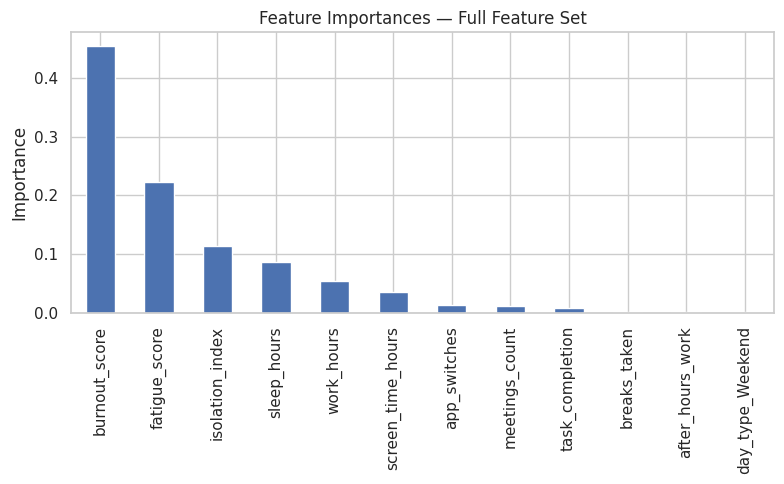

,0
burnout_score,0.454975
fatigue_score,0.222178
isolation_index,0.113108
sleep_hours,0.086759
work_hours,0.054445
screen_time_hours,0.034476
app_switches,0.013177
meetings_count,0.010695
task_completion,0.007591
breaks_taken,0.001597


In [20]:
# Random Forest feature importance to check for leakage

rf_full = full_models["Random Forest"]

feature_importances = (
    pd.Series(rf_full.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
feature_importances.plot(kind="bar")
plt.title("Feature Importances — Full Feature Set")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

display(feature_importances)

The correlation and feature importance results suggest that `burnout_score` and `fatigue_score` are likely too closely related to the target variable. To avoid target leakage, both variables are removed from the final classification feature set.

### 2.3 Final Classification Model Training

After identifying potential leakage, the final classification models are trained using the cleaned feature set. The cleaned feature set excludes `burnout_score` and `fatigue_score`, allowing the models to learn from behavioral variables rather than derived score variables.

In [21]:
# =========================================================
# 2.3 Final Classification Model Training
# =========================================================

# Remove potentially leaky features
X_clean = X.drop(columns=["burnout_score", "fatigue_score"])

# Re-split cleaned feature set
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale cleaned feature set
clean_scaler = StandardScaler()
X_train_clean_scaled = clean_scaler.fit_transform(X_train_clean)
X_test_clean_scaled = clean_scaler.transform(X_test_clean)

# Train final classification models
clean_preds, clean_models = train_classifiers(
    X_train_clean,
    X_test_clean,
    X_train_clean_scaled,
    X_test_clean_scaled,
    y_train_clean
)

print("Final cleaned classification models trained.")

Final cleaned classification models trained.


### 2.4 Estimation Models

For estimation, we use OLS models to explain burnout_score and machine learning regression models to compare predictive accuracy.

In [22]:
# =========================================================
# 2.4 Estimation Models: OLS
# =========================================================

estimation_target = pd.to_numeric(data["burnout_score"], errors="coerce").astype(float)

estimation_feature_sets = {
    "Model 1: Work Pattern OLS": [
        "work_hours",
        "screen_time_hours",
        "meetings_count",
        "breaks_taken",
        "after_hours_work",
        "app_switches",
        "day_type_Weekend"
    ],
    "Model 2: Well-Being OLS": [
        "sleep_hours",
        "task_completion",
        "isolation_index",
        "fatigue_score",
        "day_type_Weekend"
    ],
}

ols_models = {}
estimation_results = []

for model_name, feature_list in estimation_feature_sets.items():
    X_design = sm.add_constant(
        data[feature_list].apply(pd.to_numeric, errors="coerce")
    ).astype(float)

    fitted_model = sm.OLS(estimation_target, X_design).fit()
    ols_models[model_name] = fitted_model

    estimation_results.append({
        "Model": model_name,
        "Predictors": ", ".join(feature_list),
        "R-squared": fitted_model.rsquared,
        "Adjusted R-squared": fitted_model.rsquared_adj,
        "F-statistic": fitted_model.fvalue,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic
    })

estimation_results_df = pd.DataFrame(estimation_results).round(4)

print("OLS estimation models fitted.")

OLS estimation models fitted.


In [23]:
# =========================================================
# 2.4 Estimation Models: Machine Learning Regression
# =========================================================

# Linear Regression baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_clean, y_train_clean)
y_pred_lin = lin_reg.predict(X_test_clean)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_reg.fit(X_train_clean, y_train_clean)
y_pred_rf_reg = rf_reg.predict(X_test_clean)

print("Machine learning regression models fitted.")

Machine learning regression models fitted.


### 2.5 Clustering Models

We train K-Means, Agglomerative Clustering, and BIRCH using standardized behavioral features. These models are used to identify latent employee profiles without directly using the outcome labels.

In [24]:
# =========================================================
# 2.5 Clustering Models
# =========================================================

cluster_feature_columns = [
    col for col in data.columns
    if col not in ["burnout_risk", "burnout_score"]
]

cluster_data = data[cluster_feature_columns].copy()
cluster_labels_true = data["burnout_risk"].copy()

cluster_scaler = StandardScaler()
cluster_X_scaled = cluster_scaler.fit_transform(cluster_data)

clustering_models = {
    "K-Means": KMeans(
        n_clusters=3,
        n_init=20,
        random_state=42
    ),
    "Agglomerative": AgglomerativeClustering(
        n_clusters=3,
        linkage="ward"
    ),
    "BIRCH": Birch(
        n_clusters=3,
        threshold=1.5
    )
}

cluster_assignments = {}

for model_name, model in clustering_models.items():
    labels = model.fit_predict(cluster_X_scaled)
    cluster_assignments[model_name] = labels

print("Clustering models fitted.")

Clustering models fitted.


## 3. Evaluation

### 3.1 Baseline

A majority class classifier is used as the baseline. This classifier always predicts the most frequent class in the training set. It provides a minimum benchmark for determining whether the machine learning models are learning meaningful patterns beyond class frequency.

In [25]:
# =========================================================
# 3.1 Baseline
# =========================================================

majority_class = y_train_clean.mode()[0]

y_pred_baseline = pd.Series(
    [majority_class] * len(y_test_clean),
    index=y_test_clean.index
)

baseline_results_df = pd.DataFrame([{
    "Model": "Majority Class Baseline",
    "Predicted Class": majority_class,
    "Accuracy": accuracy_score(y_test_clean, y_pred_baseline),
    "Macro Precision": precision_score(y_test_clean, y_pred_baseline, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test_clean, y_pred_baseline, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test_clean, y_pred_baseline, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test_clean, y_pred_baseline, average="weighted", zero_division=0)
}]).round(4)

display(baseline_results_df)

,Model,Predicted Class,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Majority Class Baseline,0,0.51,0.255,0.5,0.3377,0.3445


### 3.2 Classification Metrics

Classification models are evaluated using accuracy, precision, recall, and F1-score. Macro averages are emphasized because they treat both classes equally.

In [26]:
# =========================================================
# 3.2 Classification Metrics
# =========================================================

classification_results = []

for model_name, y_pred in clean_preds.items():
    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_clean, y_pred),
        "Macro Precision": precision_score(y_test_clean, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test_clean, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_test_clean, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test_clean, y_pred, average="weighted", zero_division=0)
    })

classification_results_df = pd.DataFrame(classification_results).round(4)

display(classification_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.950,0.9500,0.9502,0.950,0.950
1,Random Forest,0.945,0.9454,0.9454,0.945,0.945
2,SVM,0.960,0.9601,0.9603,0.960,0.960


In [27]:
# Detailed classification reports

for model_name, y_pred in clean_preds.items():
    print(f"\n--- {model_name} ---")
    print(
        classification_report(
            y_test_clean,
            y_pred,
            target_names=["Low", "At Risk"],
            zero_division=0
        )
    )


--- Logistic Regression ---
              precision    recall  f1-score   support

         Low       0.96      0.94      0.95       204
     At Risk       0.94      0.96      0.95       196

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400


--- Random Forest ---
              precision    recall  f1-score   support

         Low       0.96      0.93      0.94       204
     At Risk       0.93      0.96      0.94       196

    accuracy                           0.94       400
   macro avg       0.95      0.95      0.94       400
weighted avg       0.95      0.94      0.94       400


--- SVM ---
              precision    recall  f1-score   support

         Low       0.97      0.95      0.96       204
     At Risk       0.95      0.97      0.96       196

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted 

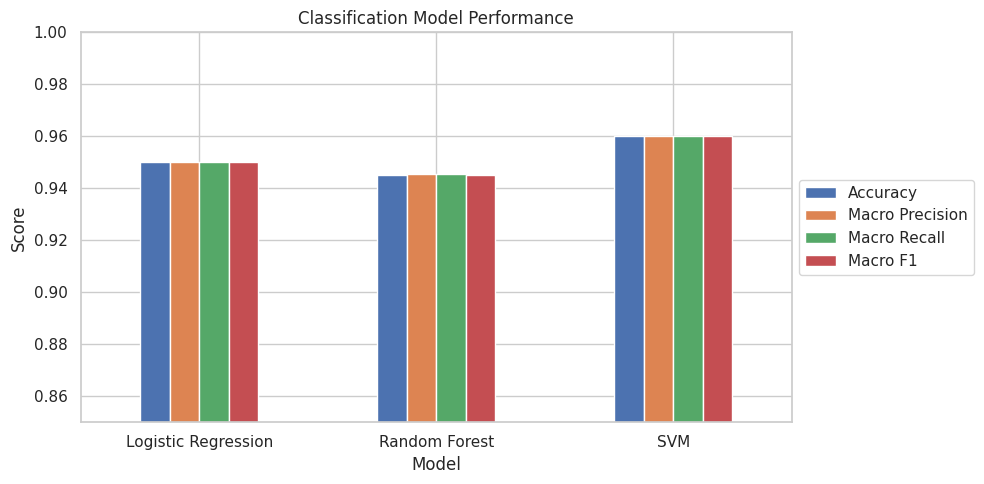

In [28]:
# Classification metrics bar chart

plot_df = classification_results_df.set_index("Model")[
    ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
]

ax = plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.ylim(0.85, 1.00)
plt.xticks(rotation=0)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

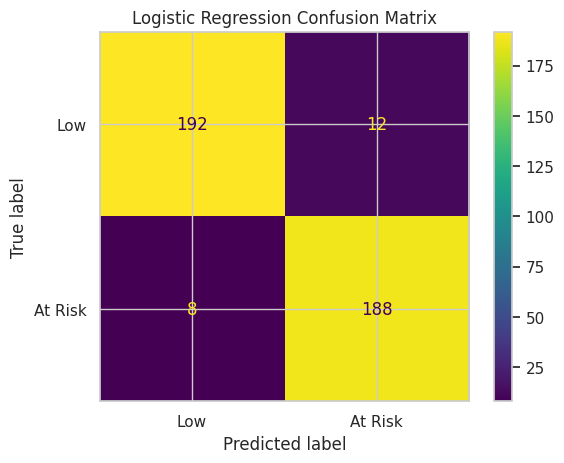

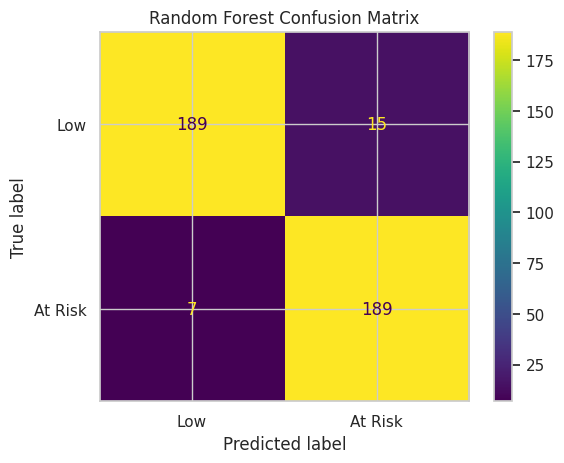

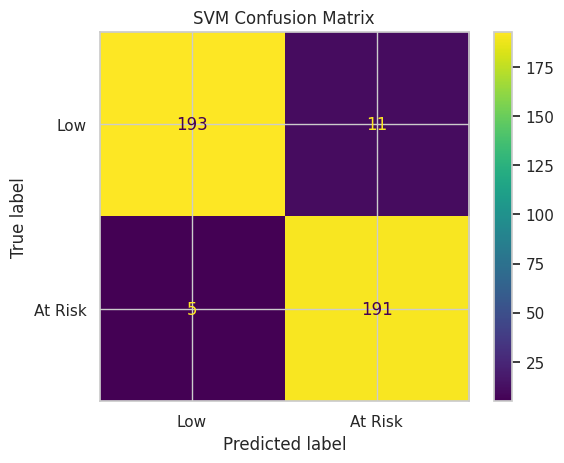

In [29]:
# Confusion matrices

for model_name, y_pred in clean_preds.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test_clean,
        y_pred,
        display_labels=["Low", "At Risk"]
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

The classification results show that all three models substantially outperform the majority-class baseline. After removing leaky features, model performance stabilizes at a more realistic level, with SVM performing best overall, followed by Logistic Regression and Random Forest.

### 3.3 Estimation Metrics

OLS models are evaluated using R-squared, Adjusted R-squared, F-statistic, AIC, and BIC. Machine learning regressors are evaluated using mean squared error.

In [30]:
# =========================================================
# 3.3 Estimation Metrics: OLS
# =========================================================

display(estimation_results_df)

for model_name, fitted_model in ols_models.items():
    print(f"\n{model_name} coefficient table:")

    coefficient_table = pd.DataFrame({
        "Coefficient": fitted_model.params,
        "Std. Error": fitted_model.bse,
        "t-statistic": fitted_model.tvalues,
        "p-value": fitted_model.pvalues
    }).round(4)

    display(coefficient_table)

,Model,Predictors,R-squared,Adjusted R-squared,F-statistic,AIC,BIC
0,Model 1: Work Pattern OLS,"work_hours, screen_time_hours, meetings_count,...",0.5057,0.5043,339.8911,15685.6407,15724.847
1,Model 2: Well-Being OLS,"sleep_hours, task_completion, isolation_index,...",0.9873,0.9872,30945.0886,8364.4266,8398.032



Model 1: Work Pattern OLS coefficient table:


,Coefficient,Std. Error,t-statistic,p-value
const,-21.0338,2.3127,-9.0948,0.0000
work_hours,2.6538,0.1258,21.0932,0.0000
screen_time_hours,2.5196,0.1020,24.7062,0.0000
meetings_count,-0.1971,0.1099,-1.7945,0.0729
breaks_taken,0.5369,0.1864,2.8798,0.0040
after_hours_work,4.1145,0.7919,5.1958,0.0000
app_switches,0.1875,0.0140,13.4311,0.0000
day_type_Weekend,1.4707,0.6062,2.4259,0.0154



Model 2: Well-Being OLS coefficient table:


,Coefficient,Std. Error,t-statistic,p-value
const,33.8654,0.6833,49.5592,0.0000
sleep_hours,-5.0468,0.0619,-81.5355,0.0000
task_completion,-0.0944,0.0039,-24.3821,0.0000
isolation_index,4.1631,0.0310,134.2126,0.0000
fatigue_score,3.6342,0.0307,118.4481,0.0000
day_type_Weekend,0.0287,0.0974,0.2942,0.7686


In [31]:
# =========================================================
# 3.3 Estimation Metrics: ML Regression
# =========================================================

mse_lin = mean_squared_error(y_test_clean, y_pred_lin)
mse_rf = mean_squared_error(y_test_clean, y_pred_rf_reg)

regression_results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MSE": mse_lin
    },
    {
        "Model": "Random Forest Regressor",
        "MSE": mse_rf
    }
]).round(4)

display(regression_results_df)

,Model,MSE
0,Linear Regression,0.0818
1,Random Forest Regressor,0.0396


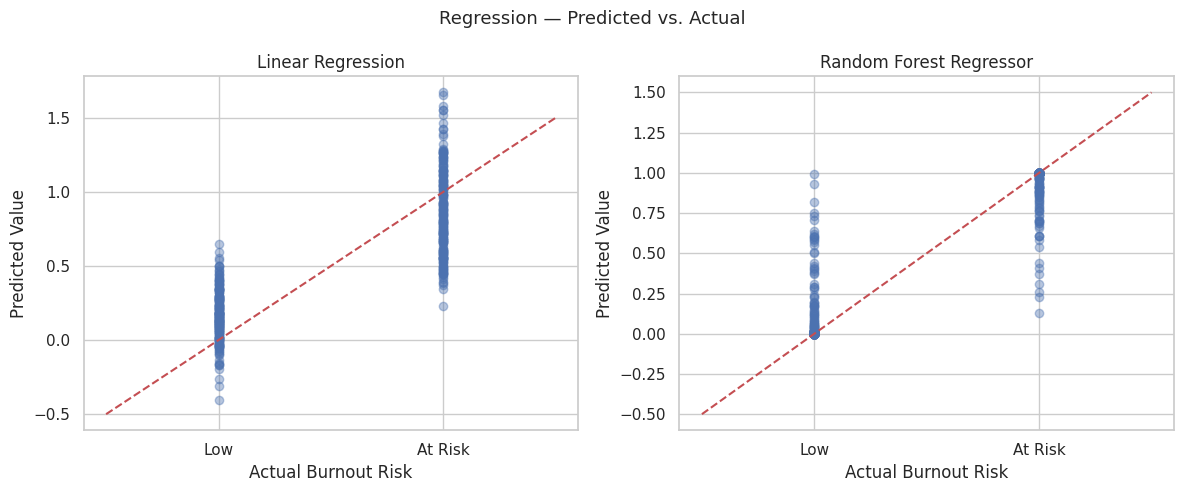

In [32]:
# Predicted vs. actual plots for ML regression

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Regression — Predicted vs. Actual", fontsize=13)

for ax, y_pred, name in zip(
    axes,
    [y_pred_lin, y_pred_rf_reg],
    ["Linear Regression", "Random Forest Regressor"]
):
    ax.scatter(y_test_clean, y_pred, alpha=0.4)
    ax.plot([-0.5, 1.5], [-0.5, 1.5], "r--", linewidth=1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low", "At Risk"])
    ax.set_xlabel("Actual Burnout Risk")
    ax.set_ylabel("Predicted Value")
    ax.set_title(name)

plt.tight_layout()
plt.show()

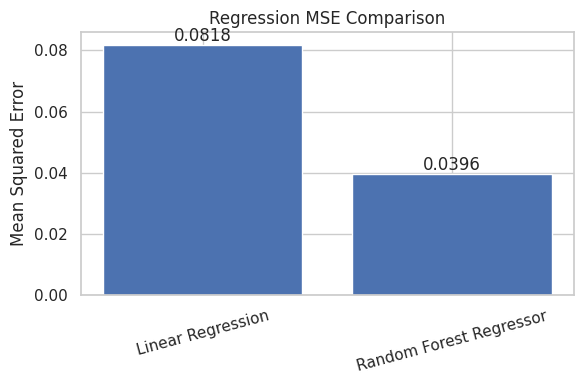

In [33]:
# Regression MSE comparison chart

plt.figure(figsize=(6, 4))

bars = plt.bar(
    regression_results_df["Model"],
    regression_results_df["MSE"]
)

plt.ylabel("Mean Squared Error")
plt.title("Regression MSE Comparison")
plt.xticks(rotation=15)

for bar, mse in zip(bars, regression_results_df["MSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{mse:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The OLS results show that the Well-Being model explains substantially more variation in `burnout_score` than the Work Pattern model. In the machine learning regression models, Random Forest achieves a lower mean squared error than Linear Regression, suggesting that nonlinear patterns improve predictive performance.

### 3.4 Clustering Metrics

Clustering models are evaluated using SSE, silhouette score, Davies-Bouldin index, Calinski-Harabasz score, and purity.

In [34]:
# =========================================================
# 3.4 Clustering Metrics
# =========================================================

def purity_score(y_true, cluster_labels):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    total = 0

    for cluster_id in np.unique(cluster_labels):
        members = y_true[cluster_labels == cluster_id]
        total += pd.Series(members).value_counts().iloc[0]

    return total / len(cluster_labels)


def cluster_sse(X, cluster_labels):
    X = np.asarray(X)
    cluster_labels = np.asarray(cluster_labels)

    sse = 0.0

    for cluster_id in np.unique(cluster_labels):
        points = X[cluster_labels == cluster_id]
        centroid = points.mean(axis=0)
        sse += ((points - centroid) ** 2).sum()

    return sse


clustering_results = []

for model_name, labels in cluster_assignments.items():
    clustering_results.append({
        "Model": model_name,
        "Clusters Found": len(np.unique(labels)),
        "SSE": cluster_sse(cluster_X_scaled, labels),
        "Silhouette": silhouette_score(cluster_X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(cluster_X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(cluster_X_scaled, labels),
        "Purity": purity_score(cluster_labels_true, labels)
    })

clustering_results_df = pd.DataFrame(clustering_results).round(4)

display(clustering_results_df)

,Model,Clusters Found,SSE,Silhouette,Davies-Bouldin,Calinski-Harabasz,Purity
0,K-Means,3,13382.7340,0.2536,1.6060,792.1655,0.9305
1,Agglomerative,3,13925.1086,0.2326,1.6673,722.4201,0.9075
2,BIRCH,3,15326.1563,0.2431,1.7037,565.1014,0.7290


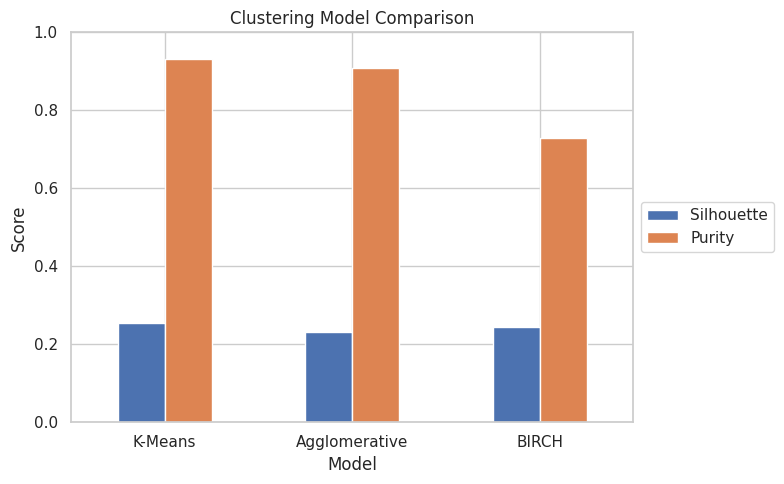

In [35]:
# Clustering metric comparison chart

cluster_plot_df = clustering_results_df.set_index("Model")[
    ["Silhouette", "Purity"]
]

cluster_plot_df.plot(kind="bar", figsize=(8, 5))

plt.title("Clustering Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

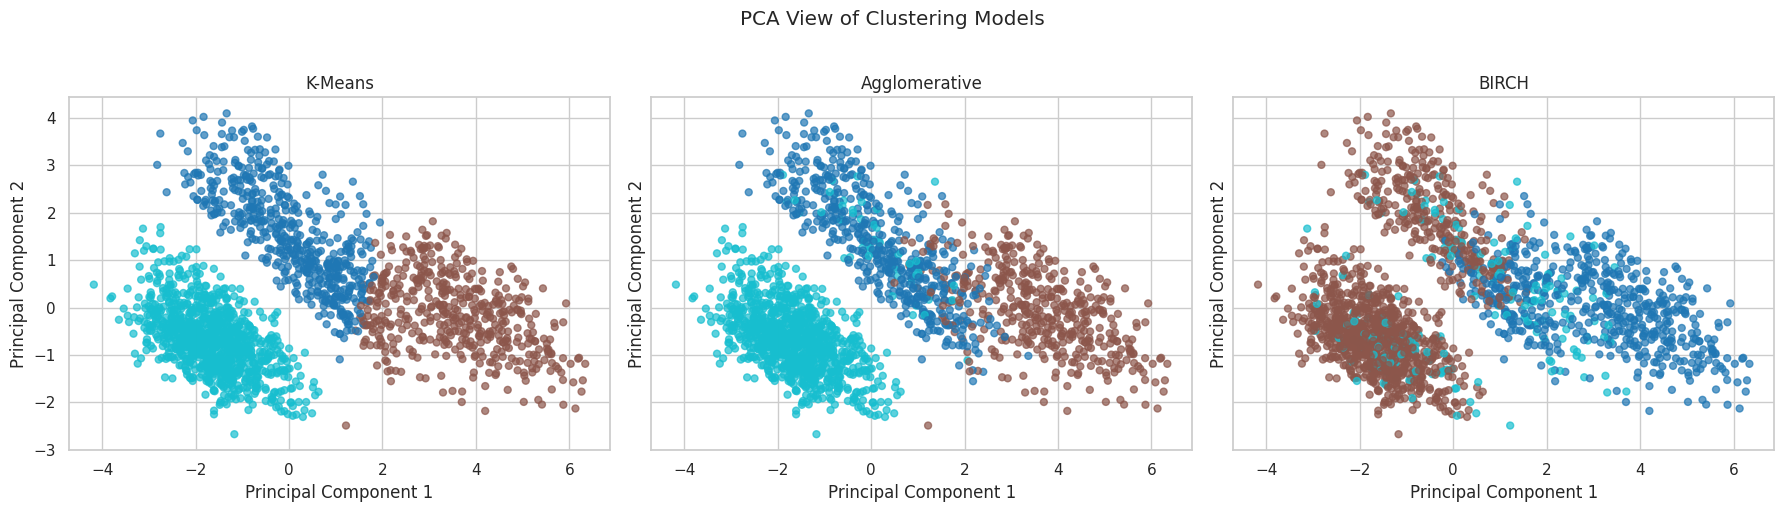

In [36]:
# PCA visualization of clustering models

pca_projection = PCA(n_components=2).fit_transform(cluster_X_scaled)
pca_df = pd.DataFrame(pca_projection, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (model_name, labels) in zip(axes, cluster_assignments.items()):
    ax.scatter(
        pca_df["PC1"],
        pca_df["PC2"],
        c=labels,
        cmap="tab10",
        alpha=0.7,
        s=25
    )
    ax.set_title(model_name)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.suptitle("PCA View of Clustering Models", y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# Cluster sizes and purity tables

for model_name, labels in cluster_assignments.items():
    print(f"\n{model_name} cluster sizes:")

    display(
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .rename("count")
        .to_frame()
    )

    print(f"{model_name} purity table against burnout_risk:")

    display(
        pd.crosstab(
            pd.Series(labels, name="cluster"),
            cluster_labels_true,
            normalize="index"
        ).round(3)
    )


K-Means cluster sizes:


,count
0,512
1,470
2,1018


K-Means purity table against burnout_risk:


burnout_risk,High,Low,Medium
cluster,,,
0,0.000,0.000,1.000
1,0.294,0.002,0.704
2,0.000,1.000,0.000



Agglomerative cluster sizes:


...

burnout_risk,High,Low,Medium
cluster,,,
0,0.000,0.000,1.000
1,0.316,0.002,0.682
2,0.000,0.957,0.043



BIRCH cluster sizes:


,count
0,552
1,1263
2,185


BIRCH purity table against burnout_risk:


burnout_risk,High,Low,Medium
cluster,,,
0,0.248,0.000,0.752
1,0.000,0.743,0.257
2,0.005,0.432,0.562


The clustering models reveal different strengths. K-Means produces compact clusters, BIRCH achieves the strongest separation, and Agglomerative Clustering aligns most closely with the observed burnout labels. The relatively modest silhouette scores suggest that burnout-related behavioral patterns overlap rather than forming perfectly distinct groups.

## 3.5 Overall Evaluation Takeaway

Overall, all classification models substantially outperform the majority-class baseline, confirming that they are learning meaningful behavioral patterns rather than simply predicting the most frequent class. After removing leaky features, classification accuracy stabilizes at approximately 94–96%, with SVM performing best overall.

The estimation results show that well-being variables explain substantially more variation in `burnout_score` than work-pattern variables, while Random Forest Regression achieves lower prediction error than Linear Regression. Clustering provides complementary insight by identifying latent behavioral profiles, although modest silhouette scores suggest that burnout-related behaviors overlap rather than forming perfectly distinct groups.

Together, the classification, estimation, and clustering results show that burnout can be predicted, explained, and profiled using behavioral data.